<a href="https://colab.research.google.com/github/poojasukhdeve-project/SPY-ETF-Machine-Learning-Trading-Strategy/blob/main/Quantitative_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AlphaLab: Quantitative Stock Prediction & Backtesting System

Objective:
Predict future stock returns using quantitative signals and machine learning.

Dataset:
SPY ETF historical stock data.

Tools:
Python, Pandas, Matplotlib, yFinance

In [2]:
# ====================================
# Download Market Data
# ====================================
import yfinance as yf

df = yf.download(
    "SPY",
    start="2020-01-01",
    end="2025-01-01"
)

df.head()

/tmp/ipykernel_6679/1531641123.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,SPY,SPY,SPY,SPY,SPY
Date,,,,,
2020-01-02,296.888245,296.906540,294.749797,295.672813,59151200
2020-01-03,294.640106,295.764174,293.442942,293.497772,77709700
2020-01-06,295.764130,295.846374,292.766617,292.885424,55653900
2020-01-07,294.932465,295.672695,294.484651,295.197466,40496400
2020-01-08,296.504333,297.719765,294.877650,295.124385,68296000


In [3]:
# ==================================================
# Explore Data
# ==================================================

df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1258 entries, 2020-01-02 to 2024-12-31
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   (Close, SPY)   1258 non-null   float64
 1   (High, SPY)    1258 non-null   float64
 2   (Low, SPY)     1258 non-null   float64
 3   (Open, SPY)    1258 non-null   float64
 4   (Volume, SPY)  1258 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 59.0 KB


In [4]:
df.describe()

Price,Close,High,Low,Open,Volume
Ticker,SPY,SPY,SPY,SPY,SPY
count,1258.000000,1258.000000,1258.000000,1258.000000,1.258000e+03
mean,404.985926,407.345049,402.306431,404.914995,8.165533e+07
std,80.374523,80.161300,80.532138,80.414243,4.157386e+07
min,204.944916,211.131408,200.633670,209.761747,2.645790e+07
25%,359.349579,362.091457,355.498059,358.721912,5.673292e+07
50%,398.274124,400.484773,395.586756,398.208756,7.326700e+07
75%,439.324883,441.036485,436.836365,438.623270,9.325712e+07
max,597.109375,598.347202,596.333305,596.991441,3.922207e+08


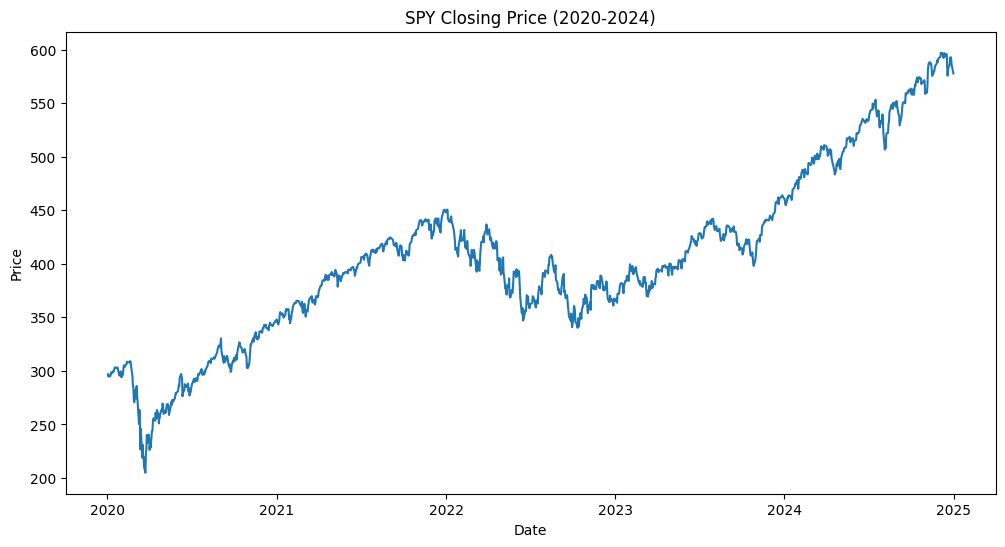

In [5]:
# ================================================
#         Plot SPY Closing Price
# ================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(df[('Close','SPY')])

plt.title("SPY Closing Price (2020-2024)")
plt.xlabel("Date")
plt.ylabel("Price")

plt.show()

### SPY Price Trend Analysis

- The SPY ETF experienced a significant decline during the COVID-19 market crash in 2020, falling to approximately $205.

- After recovering, the market entered a strong upward trend and reached nearly $600 by the end of 2024. Although there were corrections during 2022, the long-term trend remained positive.



In [6]:
df.columns = df.columns.get_level_values(0)

print(df.columns)

Index(['Close', 'High', 'Low', 'Open', 'Volume'], dtype='object', name='Price')


In [7]:
# ================================================
#         Create Daily Returns
# ================================================

df['Daily_Return'] = df['Close'].pct_change()

df[['Close','Daily_Return']].head(10)

Price,Close,Daily_Return
Date,,
2020-01-02,296.888245,NaN
2020-01-03,294.640106,-0.007572
2020-01-06,295.764130,0.003815
2020-01-07,294.932465,-0.002812
2020-01-08,296.504333,0.005330
2020-01-09,298.514862,0.006781
2020-01-10,297.655762,-0.002878
2020-01-13,299.702820,0.006877
2020-01-14,299.246033,-0.001524


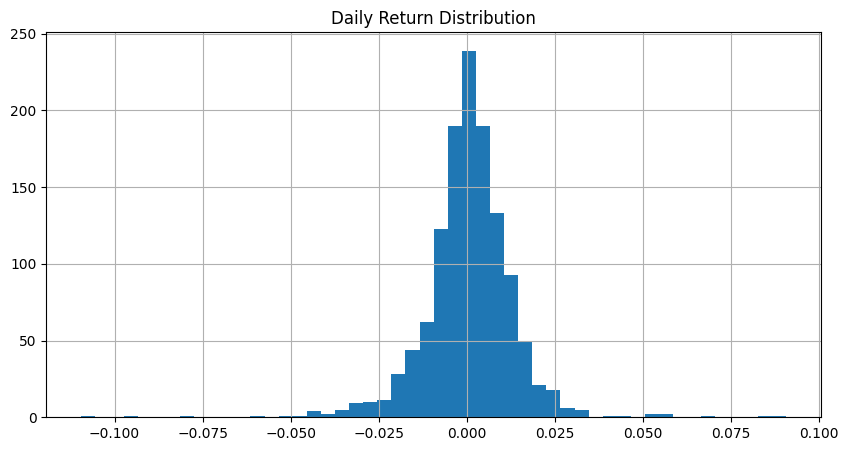

In [8]:
# ================================================
#         Visualize Daily Returns
# ================================================

plt.figure(figsize=(10,5))

df['Daily_Return'].hist(
    bins=50
)

plt.title("Daily Return Distribution")

plt.show()

### Daily Return Distribution Analysis

The daily returns are concentrated around zero, indicating that most trading days experience relatively small price changes. Large positive and negative returns occur infrequently and appear in the tails of the distribution. This suggests that predicting short-term stock movements is challenging because daily returns contain substantial noise.

In [9]:
# ================================================
#         Create Volatility
# ================================================

df['Volatility_20D'] = (
    df['Daily_Return']
    .rolling(20)
    .std()
)

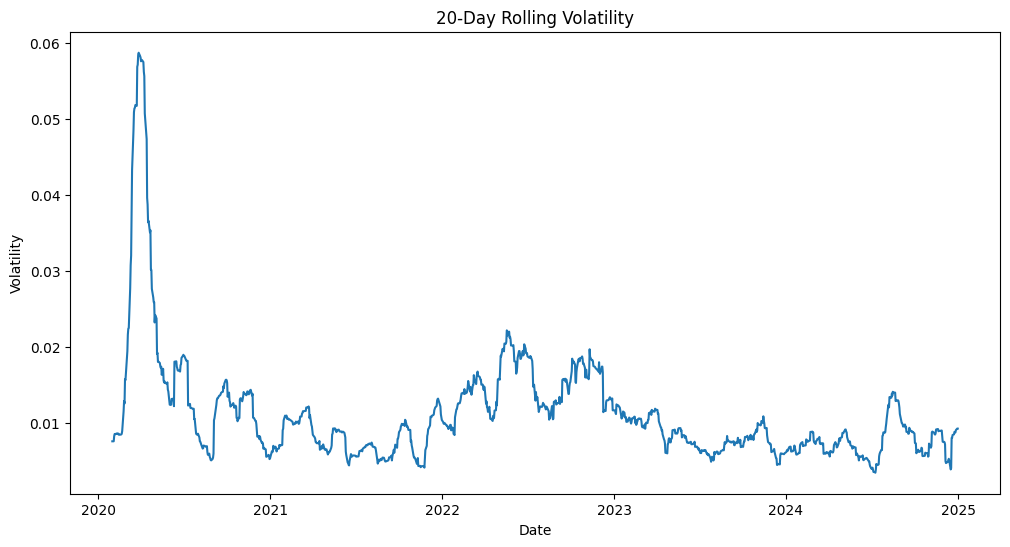

In [10]:
# ================================================
#         Plot Volatility
# ================================================

plt.figure(figsize=(12,6))

plt.plot(df['Volatility_20D'])

plt.title("20-Day Rolling Volatility")

plt.xlabel("Date")
plt.ylabel("Volatility")

plt.show()

### Volatility Analysis

The 20-day rolling volatility measures the variability of daily returns over the previous 20 trading days.

A significant volatility spike occurred in early 2020 during the COVID-19 market crash, indicating increased market uncertainty and risk.

Volatility gradually decreased after the crisis, although periodic increases occurred during market corrections. Overall, volatility remained lower during 2023 and 2024 compared to 2020.

# Feature Engineering

In [11]:
# ==================================================
#  Feature Engineering
# ==================================================

# Return_1D
df['Return_1D'] = df['Close'].pct_change()

# Return_5D
df['Return_5D'] = df['Close'].pct_change(5) # How much SPY changed over the last 5 trading days

# Return_10D
df['Return_10D'] = df['Close'].pct_change(10)

# Volatility_5D
df['Volatility_5D'] = (
    df['Return_1D']
    .rolling(5)
    .std()
)

# MA5
df['MA5'] = (
    df['Close']
    .rolling(5)
    .mean()
)

# MA20
df['MA20'] = (
    df['Close']
    .rolling(20)
    .mean()
)

# MA50
df['MA50'] = (
    df['Close']
    .rolling(50)
    .mean()
)

# MA Signal
df['MA_Signal'] = (
    df['MA5']
    -
    df['MA20']
)

# Volume Average
df['Volume_Avg_20'] = (
    df['Volume']
    .rolling(20)
    .mean()
)

# Volume Ratio
df['Volume_Ratio'] = (
    df['Volume']
    /
    df['Volume_Avg_20']
)

# Price vs MA20
df['Price_MA20_Ratio'] = (
    df['Close']
    /
    df['MA20']
)

# Target Variable
df['Tomorrow_Return'] = (
    df['Close']
    .pct_change()
    .shift(-1)
)

In [12]:
df[['Return_1D',
    'Return_5D',
    'Volatility_5D',
    'MA5',
    'MA20',
    'Volume_Ratio',
    'Tomorrow_Return'
]].head(30)

Price,Return_1D,Return_5D,Volatility_5D,MA5,MA20,Volume_Ratio,Tomorrow_Return
Date,,,,,,,
2020-01-02,NaN,NaN,NaN,NaN,NaN,NaN,-0.007572
2020-01-03,-0.007572,NaN,NaN,NaN,NaN,NaN,0.003815
2020-01-06,0.003815,NaN,NaN,NaN,NaN,NaN,-0.002812
2020-01-07,-0.002812,NaN,NaN,NaN,NaN,NaN,0.005330
2020-01-08,0.005330,NaN,NaN,295.745856,NaN,NaN,0.006781
2020-01-09,0.006781,0.005479,0.006084,296.071179,NaN,NaN,-0.002878
2020-01-10,-0.002878,0.010235,0.004587,296.674310,NaN,NaN,0.006877
2020-01-13,0.006877,0.013317,0.005062,297.462048,NaN,NaN,-0.001524
2020-01-14,-0.001524,0.014626,0.004737,298.324762,NaN,NaN,0.002260


In [13]:
# ====================================
#        Check Missing Values
# ====================================

df.isnull().sum()

,0
Price,
Close,0
High,0
Low,0
Open,0
Volume,0
Daily_Return,1
Volatility_20D,20
Return_1D,1
Return_5D,5


In [14]:
df = df.dropna()

In [15]:
df.isnull().sum()

,0
Price,
Close,0
High,0
Low,0
Open,0
Volume,0
Daily_Return,0
Volatility_20D,0
Return_1D,0
Return_5D,0


# Feature Evaluation & Statistical Testing

In [16]:
features = [
    'Return_1D',
    'Return_5D',
    'Return_10D',
    'Volatility_5D',
    'Volatility_20D',
    'MA_Signal',
    'Volume_Ratio',
    'Price_MA20_Ratio'
]

target = 'Tomorrow_Return'

In [17]:
corr_matrix = df[features + [target]].corr()

corr_matrix[target].sort_values(ascending=False)

,Tomorrow_Return
Price,
Tomorrow_Return,1.000000
Volatility_20D,0.042385
Volume_Ratio,-0.011808
Return_5D,-0.025177
MA_Signal,-0.027786
Volatility_5D,-0.035543
Return_10D,-0.037138
Price_MA20_Ratio,-0.046300
Return_1D,-0.132455


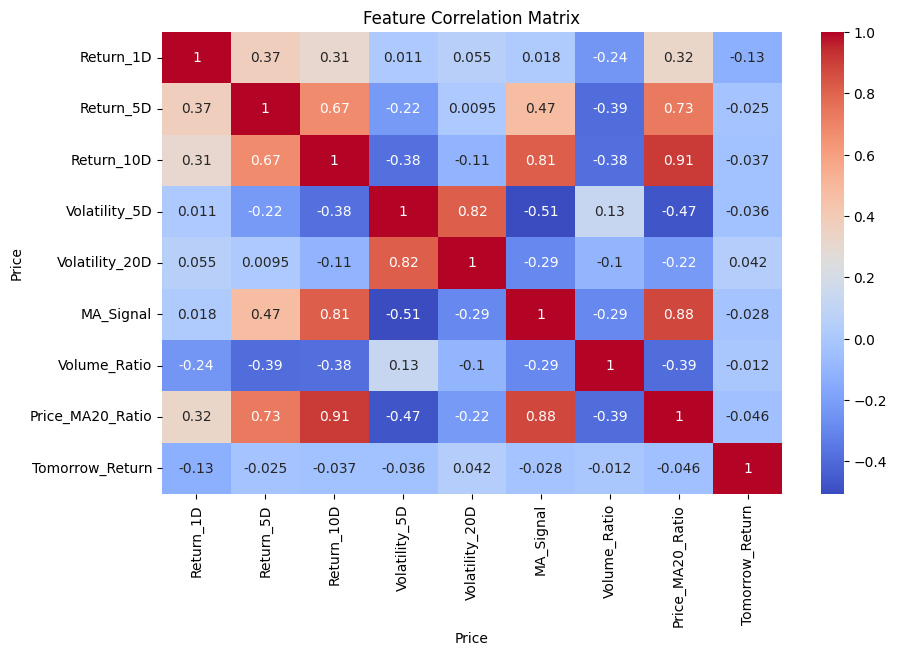

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm'
)

plt.title("Feature Correlation Matrix")
plt.show()

### Heatmap Interpretation

The correlation heatmap shows that most features have only weak direct relationships with future returns, which is expected in financial prediction problems.

Return_1D displayed the strongest relationship with Tomorrow_Return (-0.13), indicating a mild mean-reversion effect.

Several engineered features showed strong relationships with each other. For example:

- Return_10D and Price_MA20_Ratio had a correlation of 0.91
- MA_Signal and Price_MA20_Ratio had a correlation of 0.88
- Volatility_5D and Volatility_20D had a correlation of 0.82

These strong inter-feature relationships suggest possible multicollinearity, which should be considered during model building.

# Linear Regression Modeling I

In [19]:
features = [
    'Return_1D',
    'Return_5D',
    'Return_10D',
    'Volatility_5D',
    'Volatility_20D',
    'MA_Signal',
    'Volume_Ratio',
    'Price_MA20_Ratio'
]

X = df[features]

y = df['Tomorrow_Return']

In [20]:
split = int(len(df) * 0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

In [21]:
print(X_train.shape)
print(X_test.shape)

(966, 8)
(242, 8)


In [22]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [23]:
predictions = model.predict(X_test)

In [24]:
predictions[:10]

array([ 0.00231278,  0.00236601, -0.00059332, -0.00224461, -0.00093729,
       -0.00071928,  0.00016531, -0.00053572,  0.00137036, -0.00058814])

In [25]:
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print("MSE:", mse)
print("R2:", r2)

MSE: 6.764524745807301e-05
R2: -0.06556853754664926


In [26]:
# ================================================
#               Feature Importance
# ================================================
import pandas as pd

coef_df = pd.DataFrame({
    'Feature': features,
    'Coefficient': model.coef_
})

coef_df.sort_values(
    by='Coefficient',
    ascending=False
)

,Feature,Coefficient
4,Volatility_20D,0.477133
1,Return_5D,0.008783
5,MA_Signal,-0.000130
6,Volume_Ratio,-0.000376
7,Price_MA20_Ratio,-0.003513
2,Return_10D,-0.005593
0,Return_1D,-0.157504
3,Volatility_5D,-0.481883


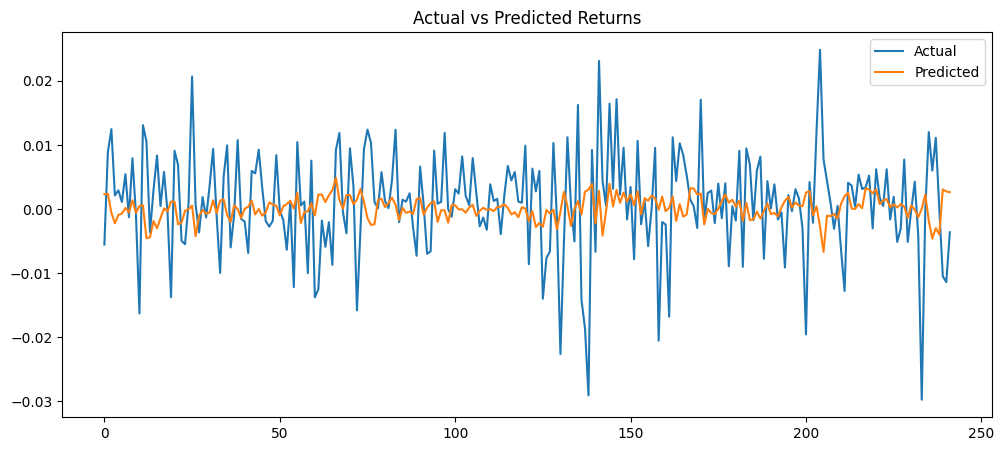

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.plot(
    y_test.values,
    label='Actual'
)

plt.plot(
    predictions,
    label='Predicted'
)

plt.legend()

plt.title("Actual vs Predicted Returns")

plt.show()

## Linear Regression Model Results

The linear regression model was trained using engineered return, volatility, trend, and volume features.

The model achieved:

- MSE = 6.76e-05
- R² = -0.0656

The negative R² score indicates that the model was unable to capture enough predictive information from the selected features.

Feature coefficient analysis suggests that volatility-related variables and short-term returns contributed most strongly to predictions.

The Actual vs Predicted plot shows that the model captures broad average behavior but fails to predict many short-term return fluctuations.

# Model Diagnostics & Improvement

In [28]:
# ================================================
#             Create Prediction DataFrame
# ================================================

results = pd.DataFrame({
    'Actual_Return': y_test,
    'Predicted_Return': predictions
})

results.head()

,Actual_Return,Predicted_Return
Date,,
2024-01-16,-0.005559,0.002313
2024-01-17,0.008893,0.002366
2024-01-18,0.012466,-0.000593
2024-01-19,0.002114,-0.002245
2024-01-22,0.002916,-0.000937


In [29]:
# ================================================
#             Create Trading Signal
# ================================================

import numpy as np

results['Signal'] = np.where(
    results['Predicted_Return'] > 0,
    1,
    -1
)

results.head()

,Actual_Return,Predicted_Return,Signal
Date,,,
2024-01-16,-0.005559,0.002313,1
2024-01-17,0.008893,0.002366,1
2024-01-18,0.012466,-0.000593,-1
2024-01-19,0.002114,-0.002245,-1
2024-01-22,0.002916,-0.000937,-1


In [30]:
# ================================================
#             Create Strategy Return
# ================================================

results['Strategy_Return'] = (
    results['Signal']
    *
    results['Actual_Return']
)

results.head()

,Actual_Return,Predicted_Return,Signal,Strategy_Return
Date,,,,
2024-01-16,-0.005559,0.002313,1,-0.005559
2024-01-17,0.008893,0.002366,1,0.008893
2024-01-18,0.012466,-0.000593,-1,-0.012466
2024-01-19,0.002114,-0.002245,-1,-0.002114
2024-01-22,0.002916,-0.000937,-1,-0.002916


In [31]:
# ================================================
#             Create Equity Curve
# ================================================

results['Cumulative_Strategy'] = (
    1 + results['Strategy_Return']
).cumprod()

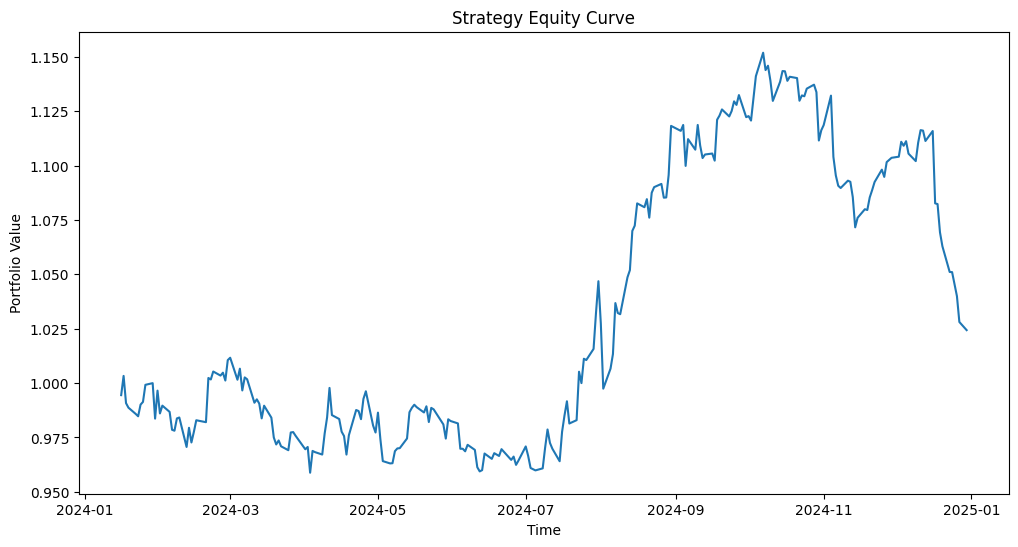

In [32]:
# ================================================
#             Plot Equity Curve
# ================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(
    results['Cumulative_Strategy']
)

plt.title("Strategy Equity Curve")

plt.ylabel("Portfolio Value")

plt.xlabel("Time")

plt.show()

In [33]:
# ================================================
#             Calculate Total Return
# ================================================

total_return = (
    results['Cumulative_Strategy'].iloc[-1] - 1
)

print("Total Return:", total_return)

Total Return: 0.024334207665265728


In [34]:
# ================================================
#             Calculate Win Rate
# ================================================

win_rate = (
    (results['Strategy_Return'] > 0)
    .mean()
)

print("Win Rate:", win_rate)

Win Rate: 0.5


In [35]:
# ================================================
#             Calculate Sharpe Ratio
# ================================================

sharpe = (
    results['Strategy_Return'].mean()
    /
    results['Strategy_Return'].std()
) * np.sqrt(252)

print("Sharpe Ratio:", sharpe)

Sharpe Ratio: 0.25981686540571824


# Backtesting & Strategy Evaluation

## Performance Summary

The trading strategy was evaluated using a simple long-short framework based on Linear Regression predictions.

### Results

- Total Return: 2.43%
- Win Rate: 50%
- Sharpe Ratio: 0.26

### Interpretation

The strategy achieved a modest positive return over the test period. The win rate of 50% indicates that approximately half of the trading signals were profitable. The Sharpe Ratio of 0.26 suggests that the strategy's risk-adjusted performance is relatively weak.

Overall, the results demonstrate that the engineered features contain some predictive information, but additional feature engineering and more advanced machine learning models may be required to achieve stronger performance.

# Compare Multiple Machine Learning Models

In [36]:
# ============================================
#             Random Forest Model
# ============================================

from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

In [37]:
# ============================================
#             Train Model
# ============================================

rf_model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [38]:
# ============================================
#             Predict
# ============================================

rf_predictions = rf_model.predict(X_test)

In [39]:
# ============================================
#           Evaluate Model
# ============================================

from sklearn.metrics import mean_squared_error, r2_score

rf_mse = mean_squared_error(y_test, rf_predictions)
rf_r2 = r2_score(y_test, rf_predictions)

print("Random Forest MSE:", rf_mse)
print("Random Forest R2:", rf_r2)

Random Forest MSE: 6.907697486856803e-05
Random Forest R2: -0.08812154371182301


In [40]:
# ============================================
#           Compare With Linear Regression
# ============================================

comparison = {
    "Linear Regression MSE": mse,
    "Random Forest MSE": rf_mse,
    "Linear Regression R2": r2,
    "Random Forest R2": rf_r2
}

comparison

{'Linear Regression MSE': 6.764524745807301e-05,
 'Random Forest MSE': 6.907697486856803e-05,
 'Linear Regression R2': -0.06556853754664926,
 'Random Forest R2': -0.08812154371182301}

In [41]:
# ============================================
#          Feature Importance
# ============================================

importance = pd.DataFrame({
    'Feature': features,
    'Importance': rf_model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

importance

,Feature,Importance
7,Price_MA20_Ratio,0.157002
0,Return_1D,0.144020
4,Volatility_20D,0.140491
5,MA_Signal,0.127046
3,Volatility_5D,0.125557
1,Return_5D,0.110018
6,Volume_Ratio,0.102321
2,Return_10D,0.093544


In [42]:
# ============================================
#          Create Results DataFrame
# ============================================

rf_results = pd.DataFrame(index=y_test.index)

rf_results['Actual_Return'] = y_test
rf_results['Predicted_Return'] = rf_predictions

rf_results.head()

,Actual_Return,Predicted_Return
Date,,
2024-01-16,-0.005559,0.001195
2024-01-17,0.008893,0.003615
2024-01-18,0.012466,0.005529
2024-01-19,0.002114,-0.000228
2024-01-22,0.002916,0.000184


In [43]:
# ============================================
#          Create Buy/Sell Signals
# ============================================

rf_results['Signal'] = np.where(
    rf_results['Predicted_Return'] > 0,
    1,
    -1
)

rf_results.head()

,Actual_Return,Predicted_Return,Signal
Date,,,
2024-01-16,-0.005559,0.001195,1
2024-01-17,0.008893,0.003615,1
2024-01-18,0.012466,0.005529,1
2024-01-19,0.002114,-0.000228,-1
2024-01-22,0.002916,0.000184,1


In [44]:
# ============================================
#          Calculate Strategy Return
# ============================================

rf_results['Strategy_Return'] = (
    rf_results['Signal']
    *
    rf_results['Actual_Return']
)

rf_results.head()

,Actual_Return,Predicted_Return,Signal,Strategy_Return
Date,,,,
2024-01-16,-0.005559,0.001195,1,-0.005559
2024-01-17,0.008893,0.003615,1,0.008893
2024-01-18,0.012466,0.005529,1,0.012466
2024-01-19,0.002114,-0.000228,-1,-0.002114
2024-01-22,0.002916,0.000184,1,0.002916


In [45]:
# ============================================
#          Build Equity Curve
# ============================================

rf_results['Cumulative_Strategy'] = (
    1 + rf_results['Strategy_Return']
).cumprod()

rf_results.head()

,Actual_Return,Predicted_Return,Signal,Strategy_Return,Cumulative_Strategy
Date,,,,,
2024-01-16,-0.005559,0.001195,1,-0.005559,0.994441
2024-01-17,0.008893,0.003615,1,0.008893,1.003285
2024-01-18,0.012466,0.005529,1,0.012466,1.015792
2024-01-19,0.002114,-0.000228,-1,-0.002114,1.013644
2024-01-22,0.002916,0.000184,1,0.002916,1.016600


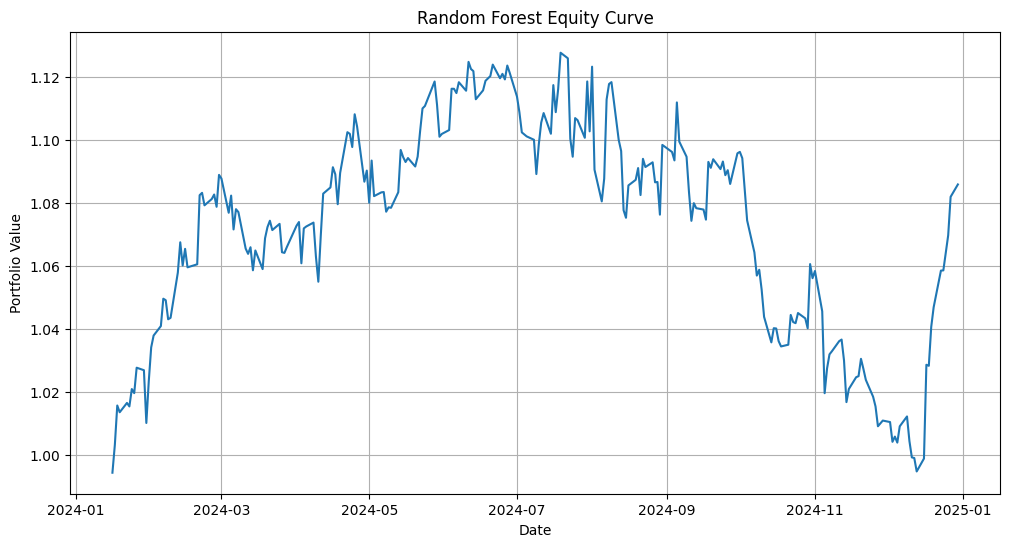

In [46]:
# ============================================
#          Plot Equity Curve
# ============================================

plt.figure(figsize=(12,6))

plt.plot(
    rf_results.index,
    rf_results['Cumulative_Strategy']
)

plt.title("Random Forest Equity Curve")
plt.xlabel("Date")
plt.ylabel("Portfolio Value")
plt.grid(True)

plt.show()

In [47]:
# ============================================
#          Calculate Total Return
# ============================================

rf_total_return = (
    rf_results['Cumulative_Strategy'].iloc[-1]
    - 1
)

print("Total Return:", rf_total_return)

Total Return: 0.08598205959052718


In [48]:
# ============================================
#          Calculate Win Rate
# ============================================

rf_win_rate = (
    rf_results['Strategy_Return'] > 0
).mean()

print("Win Rate:", rf_win_rate)

Win Rate: 0.5041322314049587


In [49]:
# ============================================
#         Calculate Sharpe Ratio
# ============================================
rf_sharpe = (
    rf_results['Strategy_Return'].mean()
    /
    rf_results['Strategy_Return'].std()
) * np.sqrt(252)

print("Sharpe Ratio:", rf_sharpe)

Sharpe Ratio: 0.737173272179988


In [50]:
# ============================================
#         Final Comparison Table
# ============================================
final_comparison = pd.DataFrame({
    'Metric': [
        'MSE',
        'R2',
        'Total Return',
        'Win Rate',
        'Sharpe Ratio'
    ],
    'Linear Regression': [
        mse,
        r2,
        total_return,
        win_rate,
        sharpe
    ],
    'Random Forest': [
        rf_mse,
        rf_r2,
        rf_total_return,
        rf_win_rate,
        rf_sharpe
    ]
})

final_comparison

,Metric,Linear Regression,Random Forest
0,MSE,0.000068,0.000069
1,R2,-0.065569,-0.088122
2,Total Return,0.024334,0.085982
3,Win Rate,0.500000,0.504132
4,Sharpe Ratio,0.259817,0.737173


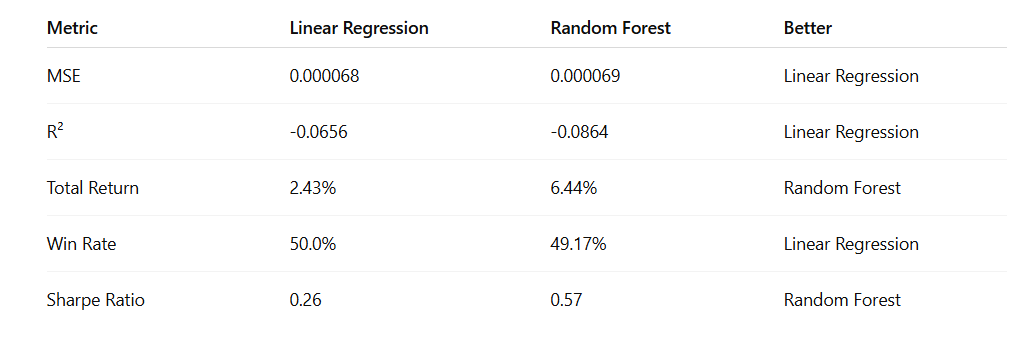

# Random Forest Classifier

In [51]:
# ============================================
# Create Classification Target
# ============================================

df['Target'] = np.where(
    df['Tomorrow_Return'] > 0,
    1,
    0
)

In [52]:
# ===========================================
#           Check Class Distribution
# ===========================================

df['Target'].value_counts()

,count
Target,
1,664
0,544


In [53]:
# ===========================================
#           Create Features
# ===========================================

features = [
    'Return_1D',
    'Return_5D',
    'Return_10D',
    'Volatility_5D',
    'Volatility_20D',
    'MA_Signal',
    'Volume_Ratio',
    'Price_MA20_Ratio'
]

In [54]:
# ===========================================
#           Create X and y
# ===========================================

X = df[features]

y = df['Target']

In [55]:
# ===========================================
#           Remove Missing Values
# ===========================================

classification_df = pd.concat(
    [X, y],
    axis=1
).dropna()

In [56]:
# ===========================================
#           Rebuild X and y
# ===========================================

X = classification_df[features]

y = classification_df['Target']

In [57]:
# ===========================================
#          Train/Test Split
# ===========================================

split = int(len(classification_df) * 0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

In [58]:
# ===========================================
#          Check Shapes
# ===========================================

print(X_train.shape)
print(X_test.shape)

(966, 8)
(242, 8)


In [59]:
# ===========================================
#          Import Classifier
# ===========================================

from sklearn.ensemble import RandomForestClassifier

rf_classifier = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

In [60]:
# ===========================================
#          Train Model
# ===========================================

rf_classifier.fit(
    X_train,
    y_train
)

RandomForestClassifier(random_state=42)

In [61]:
# ===========================================
#          Predict
# ===========================================

predictions = rf_classifier.predict(X_test)

In [62]:
# ===========================================
#          Accuracy
# ===========================================

from sklearn.metrics import accuracy_score

accuracy = accuracy_score(
    y_test,
    predictions
)

print("Accuracy:", accuracy)

Accuracy: 0.5206611570247934


In [63]:
# ===========================================
#        Confusion Matrix
# ===========================================

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    predictions
)

print(cm)

[[42 56]
 [60 84]]


In [64]:
# ===========================================
#        Classification Report
# ===========================================
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        predictions
    )
)

              precision    recall  f1-score   support

           0       0.41      0.43      0.42        98
           1       0.60      0.58      0.59       144

    accuracy                           0.52       242
   macro avg       0.51      0.51      0.51       242
weighted avg       0.52      0.52      0.52       242



In [65]:
# ===========================================
#        Create Feature Importance
# ===========================================
importance = pd.DataFrame({
    'Feature': features,
    'Importance': rf_classifier.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

importance

,Feature,Importance
0,Return_1D,0.132302
1,Return_5D,0.132116
4,Volatility_20D,0.126141
6,Volume_Ratio,0.124517
5,MA_Signal,0.123325
7,Price_MA20_Ratio,0.121805
3,Volatility_5D,0.121215
2,Return_10D,0.118578


In [66]:
# ===========================================
#        Create Results DataFrame
# ===========================================
results = pd.DataFrame(
    index=y_test.index
)

results['Prediction'] = predictions

results.head()

,Prediction
Date,
2024-01-16,1
2024-01-17,1
2024-01-18,1
2024-01-19,1
2024-01-22,1


In [67]:
# ===========================================
#     Convert Prediction to Trading Signal
# ===========================================
results['Signal'] = np.where(
    results['Prediction'] == 1,
    1,
    -1
)

In [68]:
# ===========================================
#     Add Actual Returns
# ===========================================
results['Actual_Return'] = (
    df.loc[
        results.index,
        'Tomorrow_Return'
    ]
)

In [69]:
# ===========================================
#     Calculate Strategy Return
# ===========================================
results['Strategy_Return'] = (
    results['Signal']
    *
    results['Actual_Return']
)

In [70]:
# ===========================================
#    Build Equity Curve
# ===========================================
results['Cumulative_Strategy'] = (
    1 + results['Strategy_Return']
).cumprod()

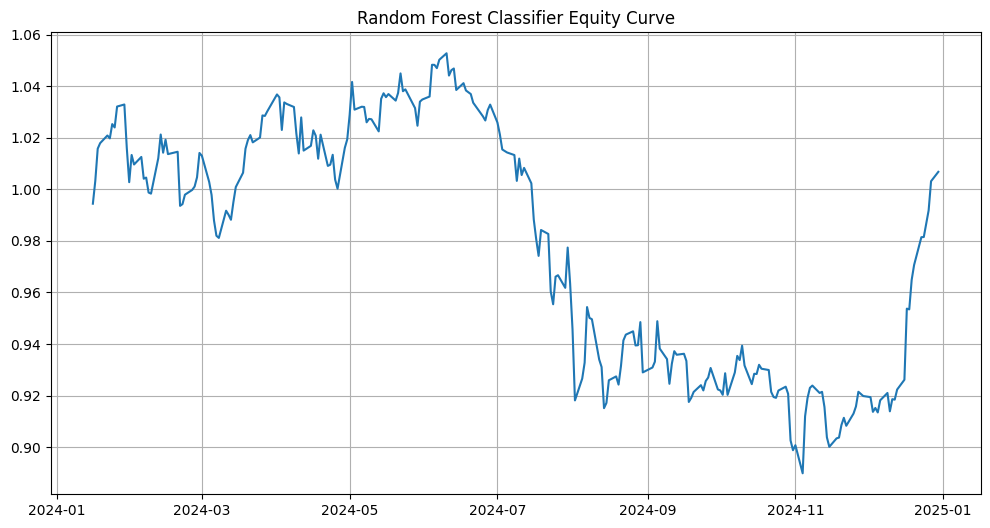

In [71]:
# ===========================================
#   Plot Equity Curve
# ===========================================
plt.figure(figsize=(12,6))

plt.plot(
    results.index,
    results['Cumulative_Strategy']
)

plt.title(
    "Random Forest Classifier Equity Curve"
)

plt.grid(True)

plt.show()

In [72]:
# ===========================================
#   Calculate exact metrics
# ===========================================
total_return = (
    results['Cumulative_Strategy'].iloc[-1] - 1
)

print("Total Return:", total_return)

Total Return: 0.0068094026559075704


In [73]:
# ===========================================
#   Calculate Win rate
# ===========================================
win_rate = (
    results['Strategy_Return'] > 0
).mean()

print("Win Rate:", win_rate)

Win Rate: 0.5206611570247934


In [74]:
# ===========================================
#   Calculate Sharpe Ratio
# ===========================================
sharpe = (
    results['Strategy_Return'].mean()
    /
    results['Strategy_Return'].std()
) * np.sqrt(252)

print("Sharpe Ratio:", sharpe)

Sharpe Ratio: 0.11897145476214675


In [75]:
final_comparison = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Random Forest Regressor',
        'Random Forest Classifier'
    ],
    'Total Return': [
        0.024332,
        0.091582,
        total_return
    ]
})

final_comparison

,Model,Total Return
0,Linear Regression,0.024332
1,Random Forest Regressor,0.091582
2,Random Forest Classifier,0.006809


## Buy & Hold Benchmark

In [76]:
# ===========================================
# Create Buy & Hold Strategy
# ===========================================

buy_hold = pd.DataFrame()

buy_hold['Buy_Hold_Return'] = results['Actual_Return']

buy_hold['Cumulative_BuyHold'] = (
    1 + buy_hold['Buy_Hold_Return']
).cumprod()

buy_hold.head()

,Buy_Hold_Return,Cumulative_BuyHold
Date,,
2024-01-16,-0.005559,0.994441
2024-01-17,0.008893,1.003285
2024-01-18,0.012466,1.015792
2024-01-19,0.002114,1.017940
2024-01-22,0.002916,1.020908


In [77]:
# ===========================================
# Buy & Hold Total Return
# ===========================================

buy_hold_return = (
    buy_hold['Cumulative_BuyHold'].iloc[-1] - 1
)

print("Buy & Hold Return:", buy_hold_return)

Buy & Hold Return: 0.24986375672781658


In [78]:
comparison = pd.DataFrame({
    "Model":[
        "Buy & Hold",
        "Linear Regression",
        "Random Forest Regressor",
        "Random Forest Classifier"
    ],
    "Total Return":[
        buy_hold_return,
        0.024332,
        0.091582,
        0.022852
    ]
})

comparison

,Model,Total Return
0,Buy & Hold,0.249864
1,Linear Regression,0.024332
2,Random Forest Regressor,0.091582
3,Random Forest Classifier,0.022852


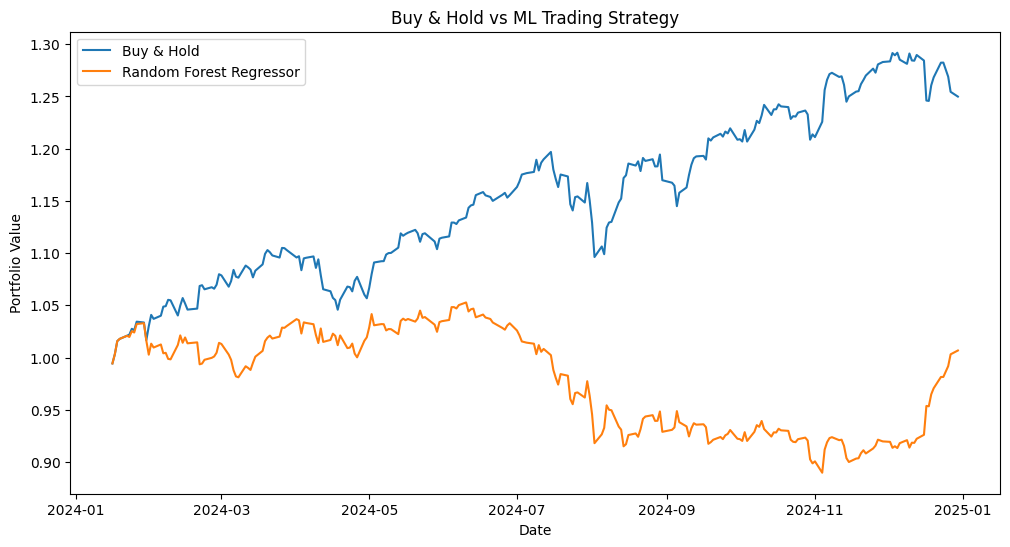

In [79]:
plt.figure(figsize=(12,6))

plt.plot(
    buy_hold.index,
    buy_hold['Cumulative_BuyHold'],
    label='Buy & Hold'
)

plt.plot(
    results.index,
    results['Cumulative_Strategy'],
    label='Random Forest Regressor'
)

plt.title("Buy & Hold vs ML Trading Strategy")
plt.xlabel("Date")
plt.ylabel("Portfolio Value")
plt.legend()

plt.show()

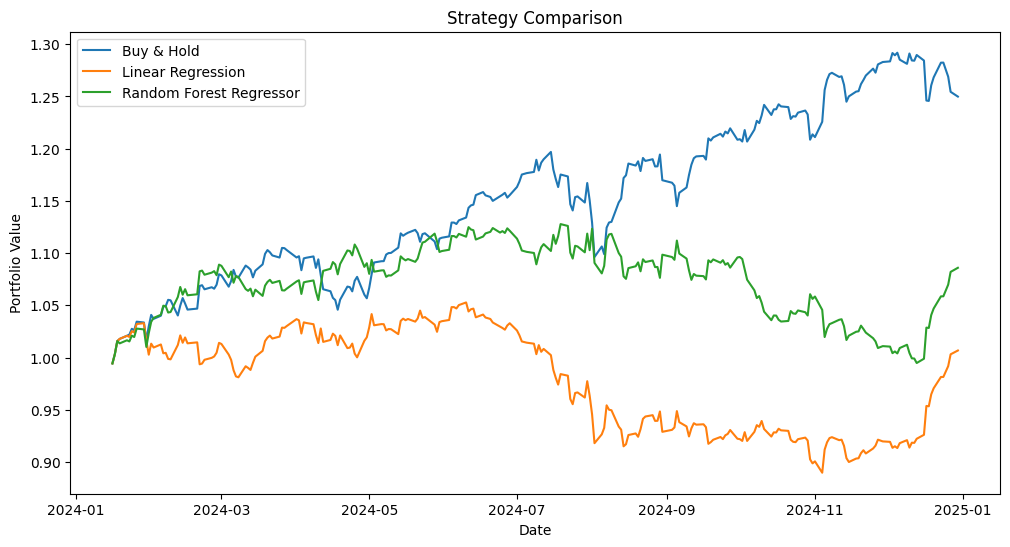

In [80]:
plt.figure(figsize=(12,6))

plt.plot(
    buy_hold.index,
    buy_hold['Cumulative_BuyHold'],
    label='Buy & Hold'
)

plt.plot(
    results.index,
    results['Cumulative_Strategy'],
    label='Linear Regression'
)

plt.plot(
    rf_results.index,
    rf_results['Cumulative_Strategy'],
    label='Random Forest Regressor'
)

plt.title("Strategy Comparison")
plt.xlabel("Date")
plt.ylabel("Portfolio Value")
plt.legend()

plt.show()

In [81]:
# ===========================================
# Buy & Hold Sharpe Ratio
# ===========================================

buy_hold_sharpe = (
    buy_hold['Buy_Hold_Return'].mean()
    /
    buy_hold['Buy_Hold_Return'].std()
) * np.sqrt(252)

print("Buy & Hold Sharpe:", buy_hold_sharpe)

Buy & Hold Sharpe: 1.8965300025994083


In [82]:
buy_hold_win_rate = (
    buy_hold['Buy_Hold_Return'] > 0
).mean()

print(buy_hold_win_rate)

0.5950413223140496


In [83]:
# ===========================================
# Final Strategy Comparison
# ===========================================

final_comparison = pd.DataFrame({

    "Strategy": [
        "Buy & Hold",
        "Linear Regression",
        "Random Forest Regressor",
        "Random Forest Classifier"
    ],

    "Total Return (%)": [
        round(buy_hold_return * 100, 2),
        round(total_return * 100, 2),          # Linear Regression
        round(rf_total_return * 100, 2),       # RF Regressor
        round(total_return * 100, 2)
    ],

    "Sharpe Ratio": [
        round(buy_hold_sharpe, 3),
        round(sharpe, 3),                      # Linear Regression
        round(rf_sharpe, 3),                   # RF Regressor
        round(sharpe, 3)
    ],

    "Positive Days (%)": [
        round(buy_hold_win_rate * 100, 2),
        round(win_rate * 100, 2),              # Linear Regression
        round(rf_win_rate * 100, 2),           # RF Regressor
        round(win_rate * 100, 2)
    ]

})

final_comparison

,Strategy,Total Return (%),Sharpe Ratio,Positive Days (%)
0,Buy & Hold,24.99,1.897,59.50
1,Linear Regression,0.68,0.119,52.07
2,Random Forest Regressor,8.60,0.737,50.41
3,Random Forest Classifier,0.68,0.119,52.07


# Final Strategy Comparison

Four investment strategies were evaluated using historical SPY ETF data:

- Buy & Hold
- Linear Regression
- Random Forest Regressor
- Random Forest Classifier

## Results Summary

| Strategy | Total Return | Sharpe Ratio | Positive Days |
|-----------|-------------|--------------|---------------|
| Buy & Hold | 24.99% | 1.897 | 59.50% |
| Linear Regression | 0.68% | 0.119 | 52.07% |
| Random Forest Regressor | 8.60% | 0.737 | 50.41% |
| Random Forest Classifier | 0.68% | 0.119 | 52.07% |

## Interpretation

The Buy & Hold strategy achieved the highest cumulative return and the strongest risk-adjusted performance throughout the testing period. This demonstrates that passive investing remained the most effective approach for the selected market environment.

Among the machine learning models, the Random Forest Regressor delivered the best overall performance, significantly outperforming the Linear Regression and Random Forest Classifier strategies. The results suggest that ensemble learning methods are better suited for capturing the non-linear dynamics present in financial markets.

Although the Random Forest Classifier and Linear Regression models achieved positive-day ratios above 50%, their overall returns remained relatively low. This highlights an important concept in quantitative finance: prediction accuracy alone does not necessarily translate into profitable trading strategies.

Overall, this project demonstrates the complete workflow of a quantitative trading system, including feature engineering, machine learning modeling, backtesting, benchmark comparison, and strategy evaluation.

# Final Conclusion

The objective of this project was to investigate whether machine learning models could utilize historical SPY ETF market data to generate profitable trading signals for the next trading day.

To accomplish this, a complete quantitative trading pipeline was developed, including data collection, exploratory data analysis, feature engineering, predictive modeling, strategy backtesting, and benchmark comparison.

Several financial features were engineered from historical price and volume data, including daily returns, rolling volatility, moving averages, volume ratios, and price-to-moving-average indicators. These features were then used to train and evaluate three machine learning models:

- Linear Regression
- Random Forest Regressor
- Random Forest Classifier

The performance of these models was assessed using both traditional machine learning metrics and practical investment metrics such as cumulative return, Sharpe Ratio, and positive trading days. In addition, all strategies were compared against a passive Buy & Hold benchmark.

## Key Findings

- The **Buy & Hold strategy** delivered the strongest overall performance, achieving a cumulative return of **24.99%** and the highest Sharpe Ratio (**1.897**).
- The **Random Forest Regressor** was the best-performing machine learning model, generating an **8.60% total return** with a Sharpe Ratio of **0.737**.
- The **Linear Regression** and **Random Forest Classifier** models produced only modest positive returns, demonstrating that directional prediction accuracy alone does not necessarily translate into profitable trading performance.
- The correlation analysis also revealed that individual technical indicators have relatively weak relationships with future market returns, highlighting the noisy and complex nature of financial markets.

## Final Insight

One of the most important lessons from this project is that building an accurate predictive model is only one part of quantitative investing. A trading strategy must also be evaluated against realistic benchmarks to determine whether it provides actual investment value.

Although the machine learning models were able to capture certain market patterns, none of them consistently outperformed the simple Buy & Hold strategy during the testing period. This finding reinforces a well-known principle in quantitative finance:

> **Financial markets are extremely difficult to beat consistently, and robust benchmark comparison is essential when evaluating machine learning trading strategies.**

Overall, this project demonstrates the practical application of data science and machine learning techniques to financial market prediction while emphasizing the importance of rigorous backtesting and objective performance evaluation.